# Strategy Router baseline — training, validation, your own queries

Track A of the router plan (SPEC d45/d46). Three stages, each one yours to read:

1. **Training** — fit the two logistic binaries on the decisive rows and look at which features drive each route.
2. **Validation** — score the router on held-out rows against the constant routes and the oracle ceiling.
3. **Your own queries** — route arbitrary text through the fitted model.

**Prerequisites**
- `data/route_labels/labels.parquet` and `data/feature_table/catalog.parquet` on disk.
- Stage 3 calls the taxonomy extractor, which needs spaCy: `poetry run python -m spacy download en_core_web_sm`.
- The optional full ablation downloads `multilingual-e5-small` (~470MB).

In [1]:
%load_ext autoreload
%autoreload 2

## 1 — Load the substrate

`exp.load()` joins the route labels to the 57 query features. `decisive_rows` keeps only the rows where one route clearly won (runner-up missed rank 1) — what the model trains and is scored on.

In [2]:
from IPython.display import display

from hybrid_search_rrf_dataset.router import (
    QueryEncoder,
    Representation,
    RouterExperiment,
    StrategyRouter,
    decisive_rows,
)

exp = RouterExperiment()
data = exp.load()
n_features = sum('.' in c for c in data.columns)
print(f'labelled rows: {len(data):,}  |  query features: {n_features}')

dec = decisive_rows(data)
print(f'decisive rows (trainable substrate): {len(dec):,}')
dec['winner'].value_counts().rename('decisive rows by winning route')

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


labelled rows: 46,142  |  query features: 72
decisive rows (trainable substrate): 5,100


winner
dense_only     3149
sparse_only    1731
pure_rrf        220
Name: decisive rows by winning route, dtype: int64

## 2 — Training

Fit two one-vs-rest logistic models on the decisive rows of the training split: one for 'is this a dense win?', one for 'is this a sparse win?'. Thresholds are then tuned so ambiguous queries fall through to rrf. The coefficient tables show which features each binary leans on (weights are on standardised features, so magnitudes compare directly).

In [3]:
# Protocol (i): 80% of each lane trains, 20% is held out.
train, test = exp.split('random_within_lane')
print(f'train rows: {len(train):,}  |  held-out rows: {len(test):,}')

router = StrategyRouter(Representation.ENGINEERED).fit(train)
router.tune_thresholds(train)
print('tuned thresholds (dense, sparse):', tuple(round(t, 3) for t in router.thresholds))

train rows: 36,917  |  held-out rows: 9,225
tuned thresholds (dense, sparse): (0.2, 0.75)


In [4]:
coef = router.coefficients()
print('features pushing hardest toward DENSE:')
display(coef.sort_values('dense_weight', ascending=False).head(10).round(3))
print('features pushing hardest toward SPARSE:')
display(coef.sort_values('sparse_weight', ascending=False).head(10).round(3))

features pushing hardest toward DENSE:


,feature,dense_weight,sparse_weight
70,syntactic_depth.statement_count,0.749,-0.658
42,structured_identifiers.host_port,0.213,-0.205
27,structured_identifiers.code_identifier,0.164,-0.146
7,natural_language_signal.natural_language_share,0.157,-0.087
53,structured_identifiers.number,0.135,-0.154
14,stopword_ratio.stopword_ratio,0.124,-0.204
21,structured_identifiers.barcode,0.117,-0.113
64,structured_identifiers.ticket_like,0.108,-0.107
68,structured_identifiers.version_string,0.107,-0.123
43,structured_identifiers.http_status_code,0.101,-0.014


features pushing hardest toward SPARSE:


,feature,dense_weight,sparse_weight
1,length.length_chars,-1.051,1.037
23,structured_identifiers.bic,-0.662,0.498
56,structured_identifiers.postal_code,-0.308,0.327
34,structured_identifiers.email,-0.233,0.278
69,syntactic_depth.nesting_depth,-0.308,0.265
22,structured_identifiers.betting_odds,-0.201,0.235
6,morphology.word_variation_share,-0.175,0.208
8,sentence_markers.acronym,-0.190,0.185
46,structured_identifiers.issn,-0.138,0.165
72,derived.avg_word_length,-0.132,0.162


## 3 — Validation

`exp.run` fits on the training portion and reports the six-column table over the held-out decisive rows, for both protocols:

- `random_within_lane` — held-out queries from lanes the model has seen.
- `holdout_lane` — the rarb-math lane held out whole (a collection never seen).

`headroom_captured` is where the router lands between the best constant route (0.0) and the oracle ceiling (1.0). The numbers are yours to read.

In [18]:
cols = [
    'protocol', 'representation', 'n_test_decisive',
    'const_dense_only', 'const_pure_rrf', 'const_sparse_only',
    'oracle', 'router', 'headroom_captured', 't_dense', 't_sparse',
]
result = exp.run(representations=[Representation.ENGINEERED], all_rows=True)
result[cols].round(3)

holdout_lane·engineered: 100%|██████████| 2/2 [00:00<00:00, 18.17it/s, headroom=0.028, n=206]


,protocol,representation,n_test_decisive,const_dense_only,const_pure_rrf,const_sparse_only,oracle,router,headroom_captured,t_dense,t_sparse
0,random_within_lane,engineered,1021,0.631,0.208,0.367,0.975,0.700,0.201,0.30,0.70
1,holdout_lane,engineered,206,0.607,0.185,0.430,1.000,0.618,0.028,0.25,0.65


### Diagnostic — sparse binary or tuner?

Everything routes dense because `t_dense ≈ 0.2` (dense always fires) and `t_sparse = 0.75` (sparse almost never does). Two possible causes, different fixes:

1. **Discrimination lost** — the sparse binary can't tell sparse wins from dense wins on the new data. The two `p_sparse` histograms below overlap, AUC near 0.5. No threshold fixes this; it's a feature/coverage problem.
2. **Threshold miscalibrated** — the histograms separate (AUC well above 0.5) but the tuner parked `t_sparse` on a flat plateau. The heatmap shows whether 0.75 is a sharp optimum or an arbitrary point on a ridge.

Uses the §2 `router` (fit on `train`) and the held-out `test` split — nothing here re-fits.

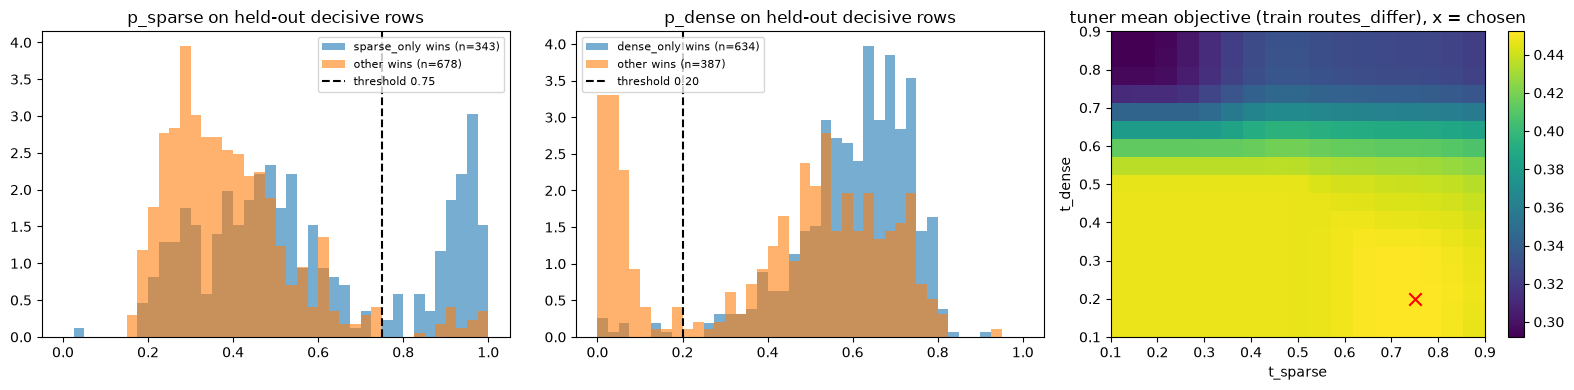

AUC — p_sparse vs sparse wins: 0.718  |  p_dense vs dense wins: 0.714
objective: optimum 0.4522  |  best with sparse muted (t_sparse=0.9): 0.4480
grid points within 0.002 of optimum: 22/289 (large = plateau, tuner choice arbitrary)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

from hybrid_search_rrf_dataset.router import (
    THRESHOLD_GRID_MAX,
    THRESHOLD_GRID_MIN,
    THRESHOLD_GRID_STEPS,
    StrategyName,
    _route_indices,
    _routes_differ,
    _score_matrix,
)

dec_test = decisive_rows(test)
p_dense, p_sparse = router._probabilities(dec_test)
winner = dec_test['winner'].to_numpy()
t_dense, t_sparse = router.thresholds

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bins = np.linspace(0, 1, 41)
for ax, probs, t, name, target in (
    (axes[0], p_sparse, t_sparse, 'p_sparse', StrategyName.SPARSE_ONLY),
    (axes[1], p_dense, t_dense, 'p_dense', StrategyName.DENSE_ONLY),
):
    is_target = winner == target
    ax.hist(probs[is_target], bins=bins, alpha=0.6, density=True,
            label=f'{target!s} wins (n={int(is_target.sum())})')
    ax.hist(probs[~is_target], bins=bins, alpha=0.6, density=True,
            label=f'other wins (n={int((~is_target).sum())})')
    ax.axvline(t, color='k', ls='--', label=f'threshold {t:.2f}')
    ax.set_title(f'{name} on held-out decisive rows')
    ax.legend(fontsize=8)

# The tuner's objective surface, on the exact frame tune_thresholds used.
tune = train[_routes_differ(train)]
pd_t, ps_t = router._probabilities(tune)
scores = _score_matrix(tune)
rows = np.arange(len(tune))
grid = np.linspace(THRESHOLD_GRID_MIN, THRESHOLD_GRID_MAX, THRESHOLD_GRID_STEPS)
surface = np.array([
    [scores[rows, _route_indices(pd_t, ps_t, t_d, t_s)].mean() for t_s in grid]
    for t_d in grid
])
im = axes[2].imshow(surface, origin='lower', aspect='auto',
                    extent=(grid[0], grid[-1], grid[0], grid[-1]))
axes[2].scatter([t_sparse], [t_dense], color='red', marker='x', s=80)
axes[2].set_xlabel('t_sparse')
axes[2].set_ylabel('t_dense')
axes[2].set_title('tuner mean objective (train routes_differ), x = chosen')
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

auc_sparse = roc_auc_score(winner == StrategyName.SPARSE_ONLY, p_sparse)
auc_dense = roc_auc_score(winner == StrategyName.DENSE_ONLY, p_dense)
plateau = int((surface >= surface.max() - 0.002).sum())
print(f'AUC — p_sparse vs sparse wins: {auc_sparse:.3f}  |  p_dense vs dense wins: {auc_dense:.3f}')
print(f'objective: optimum {surface.max():.4f}  |  best with sparse muted (t_sparse=0.9): {surface[:, -1].max():.4f}')
print(f'grid points within 0.002 of optimum: {plateau}/{surface.size} (large = plateau, tuner choice arbitrary)')

In [20]:
# Follow-up: who are the sparse winners the features can't see?
# Splits held-out sparse wins at t_sparse: 'visible' = the confident cluster
# the router already captures, 'invisible' = the overlap zone. Runs on the
# previous cell's kernel state (dec_test, p_sparse, p_dense, t_sparse).
import pandas as pd

from hybrid_search_rrf_dataset.router import _derive_engineered, _is_engineered

dt = dec_test.copy()
dt['p_sparse'], dt['p_dense'] = p_sparse, p_dense
sparse_win = dt['winner'] == StrategyName.SPARSE_ONLY
dense_win = dt['winner'] == StrategyName.DENSE_ONLY
visible = sparse_win & (dt['p_sparse'] >= t_sparse)
invisible = sparse_win & (dt['p_sparse'] < t_sparse)
print(f'held-out sparse winners: {int(sparse_win.sum())}  |  '
      f'visible (p_sparse ≥ {t_sparse:.2f}): {int(visible.sum())}  |  '
      f'invisible: {int(invisible.sum())}')

# 1 — which lanes hold them. A lane concentrated in 'invisible' is a query
# archetype the extractors cannot express; that's the generation/extractor target.
lanes = pd.DataFrame({
    'visible': dt.loc[visible, 'dataset'].value_counts(),
    'invisible': dt.loc[invisible, 'dataset'].value_counts(),
}).fillna(0).astype(int)
lanes['invisible_share'] = (lanes['invisible'] / lanes.sum(axis=1)).round(2)
display(lanes.sort_values('invisible', ascending=False).head(15))

# 2 — feature profiles, in units of overall std (comparable across features).
eng = _derive_engineered(dt)
feat_cols = [c for c in eng.columns if _is_engineered(c)]
std = eng[feat_cols].std().replace(0, np.nan)
profile = pd.DataFrame({
    'sparse_visible': eng.loc[visible, feat_cols].mean(),
    'sparse_invisible': eng.loc[invisible, feat_cols].mean(),
    'dense_wins': eng.loc[dense_win, feat_cols].mean(),
})
profile['vis_vs_invis'] = (profile['sparse_visible'] - profile['sparse_invisible']) / std
profile['invis_vs_dense'] = (profile['sparse_invisible'] - profile['dense_wins']) / std

print('what makes the visible cluster visible (top |vis_vs_invis|):')
display(profile.reindex(profile['vis_vs_invis'].abs()
        .sort_values(ascending=False).index).head(10).round(2))
print('does ANY feature still separate invisible sparse wins from dense wins?')
print('(all |invis_vs_dense| small = truly invisible, no threshold or reweighting helps)')
display(profile.reindex(profile['invis_vs_dense'].abs()
        .sort_values(ascending=False).index).head(10).round(2))

# 3 — faces to the numbers.
print('sample of invisible sparse winners:')
for _, r in dt[invisible].sample(n=min(12, int(invisible.sum())), random_state=0).iterrows():
    q = ' '.join(str(r['query']).split())
    print(f"  {r['dataset']:>24s}  p_sparse={r['p_sparse']:.2f}  {q[:110]}")

held-out sparse winners: 343  |  visible (p_sparse ≥ 0.75): 99  |  invisible: 244


,visible,invisible,invisible_share
dataset,,,
orcas,3,49,0.94
scirgen-geo-en,2,39,0.95
limit,0,28,1.00
msmarco-passage-dev,0,20,1.00
gooaq,0,19,1.00
webfaq-eng,0,18,1.00
rarb-math,3,17,0.85
lotte-technology-forum,0,12,1.00
crumb-legal-qa,0,8,1.00


what makes the visible cluster visible (top |vis_vs_invis|):


,sparse_visible,sparse_invisible,dense_wins,vis_vs_invis,invis_vs_dense
structured_identifiers.bic,0.89,0.00,0.01,2.77,-0.02
length.length_words,227.54,17.89,21.11,2.57,-0.04
length.length_chars,1365.72,103.37,120.27,2.41,-0.03
syntactic_depth.statement_count,23.51,2.39,2.82,2.36,-0.05
sentence_markers.negation,2.73,0.15,0.19,2.14,-0.03
sentence_markers.acronym,4.49,0.14,0.11,2.12,0.01
structured_identifiers.legal_citation,2.35,0.00,0.02,2.08,-0.01
syntactic_depth.nesting_depth,10.35,3.94,3.93,1.97,0.00
structured_identifiers.number,13.18,0.66,1.05,1.87,-0.06
coordination.widest_list_size,2.96,0.65,0.51,1.63,0.10


does ANY feature still separate invisible sparse wins from dense wins?
(all |invis_vs_dense| small = truly invisible, no threshold or reweighting helps)


,sparse_visible,sparse_invisible,dense_wins,vis_vs_invis,invis_vs_dense
stopword_ratio.stopword_ratio,0.31,0.36,0.41,-0.27,-0.30
morphology.word_variation_share,0.17,0.24,0.20,-0.36,0.24
natural_language_signal.natural_language_share,0.37,0.38,0.41,-0.05,-0.22
derived.avg_word_length,5.90,5.68,5.53,0.22,0.14
structured_identifiers.alt_geocoding,0.00,0.01,0.00,-0.13,0.13
derived.identifier_density,0.12,0.06,0.04,0.49,0.13
structured_identifiers.currency_amount,0.04,0.09,0.03,-0.10,0.11
coordination.widest_list_size,2.96,0.65,0.51,1.63,0.10
structured_identifiers.uri,0.02,0.01,0.00,0.08,0.10
structured_identifiers.ticket_like,0.01,0.00,0.00,0.14,0.09


sample of invisible sparse winners:
                     limit  p_sparse=0.40  Who likes Curling?
                     limit  p_sparse=0.51  Who likes Sparrows?
                     limit  p_sparse=0.40  Who likes Water Polo?
       msmarco-passage-dev  p_sparse=0.36  the _______ is a numeric measure of the strength of a linear relationship.
              trec-dl-2022  p_sparse=0.42  what hazards come with making paint
             miracl-en-dev  p_sparse=0.31  How did the SCOTUS rule in eminent domain?
                     limit  p_sparse=0.48  Who likes Comets?
                 rarb-math  p_sparse=0.46  Problem: A Senate committee has 8 Republicans and 6 Democrats. In how many ways can we form a subcommittee of 
            scirgen-geo-en  p_sparse=0.51  I don't understand the challenges faced when using cosmic ray neutron data for soil moisture measurement.
                 rarb-math  p_sparse=0.59  Problem: Sally, Wei-Hwa, and Zoe are playing a game of marbles involving first arran

In [8]:
# Full three-representation ablation (engineered / e5 embedding / both).
# Uncomment to run — the first call downloads multilingual-e5-small (~470MB)
# and embeds every query once (cached to data/route_labels/e5_embeddings.parquet),
# so later runs are fast.

exp_full = RouterExperiment(encoder=QueryEncoder())
runner_result= exp_full.run(autofusion=True,  autofusion_sample=50)

holdout_lane·both: 100%|██████████| 6/6 [00:00<00:00, 14.79it/s, headroom=0.053, n=206]            


In [9]:
runner_result[cols].round(3)

,protocol,representation,n_test_decisive,const_dense_only,const_pure_rrf,const_sparse_only,oracle,router,headroom_captured,t_dense,t_sparse
0,random_within_lane,engineered,1021,0.631,0.208,0.367,0.975,0.709,0.226,0.20,0.70
1,random_within_lane,embedding,1021,0.631,0.208,0.367,0.975,0.745,0.333,0.10,0.65
2,random_within_lane,both,1021,0.631,0.208,0.367,0.975,0.753,0.354,0.30,0.65
3,holdout_lane,engineered,206,0.607,0.185,0.430,1.000,0.619,0.031,0.25,0.75
4,holdout_lane,embedding,206,0.607,0.185,0.430,1.000,0.573,-0.087,0.10,0.65
5,holdout_lane,both,206,0.607,0.185,0.430,1.000,0.628,0.053,0.15,0.65
6,random_within_lane,auto_fusion,50,0.617,0.221,0.372,0.983,0.501,-0.317,NaN,NaN
7,holdout_lane,auto_fusion,50,0.603,0.187,0.434,1.000,0.291,-0.786,NaN,NaN


## 4 — Test on your own queries

Fit on all decisive rows, then route whatever you type. This is the serving path: `predict` extracts the query's features inline and applies the same rule. Needs `en_core_web_sm` (spaCy).

In [ ]:
from src.hybrid_search_rrf_dataset.router import AutoFusionRouter

auto_fusion = AutoFusionRouter()

In [21]:
served = StrategyRouter(Representation.ENGINEERED).fit(data)
served.tune_thresholds(data)

my_queries = [
    'what are the side effects of DHA',
    'python sort list of dicts by key',
    'CVE-2021-44228 log4j remote code execution',
    'how do mRNA vaccines work',
    'SELECT * FROM users WHERE id = 42',
]
for q in my_queries:
    print(f'{served.predict(q)!s:12s}  {q}')

dense_only    what are the side effects of DHA
dense_only    python sort list of dicts by key
dense_only    CVE-2021-44228 log4j remote code execution
dense_only    how do mRNA vaccines work
dense_only    SELECT * FROM users WHERE id = 42


In [11]:
# Type your own query:
served.predict('#ABBSSS')

<StrategyName.DENSE_ONLY: 'dense_only'>

In [12]:
served.explain('Looking for qdrant_client.http.models.FormulaQuery')

{'query': 'Looking for qdrant_client.http.models.FormulaQuery',
 'route': <StrategyName.DENSE_ONLY: 'dense_only'>,
 'p_dense': 0.4443321274147025,
 'p_sparse': 0.5904714650495779,
 't_dense': 0.25,
 't_sparse': 0.75,
 'dense_fires': True,
 'sparse_fires': False}

In [13]:
served.explain('http://localhost.com') # URIs have zero training coverage 

{'query': 'http://localhost.com',
 'route': <StrategyName.DENSE_ONLY: 'dense_only'>,
 'p_dense': 0.3091287959162702,
 'p_sparse': 0.6491797449611939,
 't_dense': 0.25,
 't_sparse': 0.75,
 'dense_fires': True,
 'sparse_fires': False}

In [21]:
served.explain('qdrant_client.http.models.FormulaQuery')

{'query': 'qdrant_client.http.models.FormulaQuery',
 'route': <StrategyName.DENSE_ONLY: 'dense_only'>,
 'p_dense': 0.7343243773665759,
 'p_sparse': 0.29132406733559785,
 't_dense': 0.30000000000000004,
 't_sparse': 0.6,
 'dense_fires': True,
 'sparse_fires': False}

In [17]:
served.predict('CVE-1223')

<StrategyName.PURE_RRF: 'pure_rrf'>

In [26]:
served.predict('http://localhost.com')

<StrategyName.DENSE_ONLY: 'dense_only'>

In [18]:
from query_taxonomy.features import FeatureExtractor

fe = FeatureExtractor()

In [23]:
fe.resolve('http://localhost.com')

QueryFeatures(query_text='http://localhost.com', spans={<FeatureGroup.STRUCTURED_IDENTIFIERS: 'structured_identifiers'>: {'uri': [FeatureSpan(text='http://localhost.com', start=0, end=20)]}}, stats={<FeatureGroup.STATISTICAL_METRICS: 'statistical_metrics'>: {'length': [FeatureStat(name='length_words', value=3.0), FeatureStat(name='length_chars', value=20.0)], 'stopword_ratio': [FeatureStat(name='stopword_ratio', value=0.0)]}}, tfs={<FeatureGroup.STRUCTURED_IDENTIFIERS: 'structured_identifiers'>: {'uri': 1}})

In [22]:
from query_taxonomy.banks.tech import URIBank


uri_detector = URIBank()

uri_detector.compute("http://localhost.com")

[FeatureSpan(text='http://localhost.com', start=0, end=20)]

In [ ]:
from hybrid_search_rrf_dataset.router import _extract_features

features = _extract_features(None, "http://localhost.com")
features

{'structured_identifiers.uri': 1,
 'length.length_words': 3.0,
 'length.length_chars': 20.0,
 'stopword_ratio.stopword_ratio': 0.0,
 'natural_language_signal.natural_language_share': 0.0,
 'morphology.word_variation_share': 0.0,
 'syntactic_depth.nesting_depth': 0.0,
 'syntactic_depth.statement_count': 1.0,
 'coordination.widest_list_size': 0.0}

## 5 — How the router decides

Not a three-way classifier. Two independent one-vs-rest logistic binaries plus a hedge rule:

- `dense_fires = p_dense >= t_dense`
- `sparse_fires = p_sparse >= t_sparse`
- Neither fires → **`pure_rrf`** — the safe hedge; RRF runs both retrievers and fuses their rankings, so it cannot lose to the better of the two on top-10 metrics.
- One fires → that route.
- Both fire → whichever `p` is higher.

`pure_rrf` is never a trained class. It exists only as the residual of the hedge — the route the model picks when it is not confident enough in either alternative. The thresholds `t_dense`, `t_sparse` are learned from data by grid-searching the pair that maximizes the router's mean objective on a validation frame.

### Why `t_sparse > t_dense` is normal

The LR uses `class_weight="balanced"` on each binary. Because the decisive training set is ~74% dense / 20% sparse / 6% rrf, class balancing shifts the two binaries' output distributions apart:

- **Dense binary** — positive class dominates training. Balancing lowers its typical `p_dense`; the population sits mostly in [0.3, 0.6].
- **Sparse binary** — positive class is minority. Balancing raises its typical `p_sparse`; the population sits mostly in [0.5, 0.9].

The thresholds compensate for that shift. `t_sparse > t_dense` is **not a bias**; it is the calibration that puts the two binaries back on comparable operating points. Class imbalance is handled by `class_weight` in the loss; the thresholds handle the resulting probability-scale asymmetry at the decision layer. So `p_sparse = 0.826` and `p_dense = 0.826` do not mean the same "level of confidence" — the thresholds translate each into the right fire/hedge decision given how its binary was trained.

## 6 — What changed from the baseline

Compared to the version that first went to §3 (`router 0.678`, `headroom_captured = −0.251` on `random_within_lane` — losing to always-dense by six points), the current build lands at **`router 0.751`, `+0.057`**. Two setup-side refactors, no new data or external features.

**F2 — feature engineering.** Three derived columns computed at training and serving time (no catalog rebuild), plus one drop:

- `derived.identifier_density = sum(structured_identifiers.*) / length_words` — how much of the query is identifier-shaped.
- `derived.avg_word_length = length_chars / length_words` — the informative diff of the two length signals; long chars/word = technical vocabulary that BM25 struggles with morphologically.
- `derived.short_id_query = (identifier_density > 0) & (length_words ≤ 5)` — a boolean cross the LR cannot see linearly.
- `length.length_words` dropped after `avg_word_length` lands. In the shipped baseline it was the top sparse-puller at +1.55 — a **corpus artifact** (long BEIR / CRUMB queries happened to lean sparse), not a policy signal. Exposing the informative axis and dropping the correlated raw column dissolved the artifact.

The coefficient table in §2 shows the new picture: `derived.identifier_density` at −0.349 dense / +0.220 sparse, `derived.avg_word_length` at +0.207 dense / −0.218 sparse, `length.length_chars` still carrying part of the length signal at +0.441 sparse but no longer dominating.

**F1' — threshold tuner scope.** The tuner grid-searches `(t_dense, t_sparse)` by maximizing the router's mean objective on a validation frame. Originally that frame was "all shapes" (routes_differ + all_tied + all_zero). Measurement showed **67% of the tune frame is threshold-invariant** — all_tied rows have identical scores across route choices, all_zero rows have zero for every route. Both contribute constants to the mean regardless of threshold, diluting the argmax. The tuner was landing at `t_sparse=0.9` (sparse effectively never fires) because on the diluted objective it could not distinguish the sparse binary's genuine signal from noise.

Fix: restrict the tuner's frame to `routes_differ` rows — the ones where threshold choice actually changes the outcome. Empirical optimum shifts to `t_sparse ≈ 0.6–0.8`, sparse fires meaningfully on identifier-bearing queries, and the aggregate lift on `random_within_lane` follows.

The full amendment history — F1 was tried first as an inverse-frequency-weighted mean, sent the router into an "always rrf" degeneracy on the imbalanced argmax distribution, and was reverted as a documented negative result before F1' landed — lives in SPEC decision 47.

## 7 — Where the router still fails, and the fix path

The improved router beats the constant on aggregate, but the `explain` call above surfaces a concrete gap. For `http://localhost.com`:

```
{'p_dense': 0.993, 'p_sparse': 0.008, 'route': 'dense_only'}
```

The URL is confidently routed to dense — the wrong answer, since BM25 would trivially win on a query composed entirely of high-IDF mostly-OOV tokens.

**Root cause is coverage, not modeling.** Of the 2,510 decisive training rows, only 3 have `structured_identifiers.uri > 0`. All 3 are **long documents** (19–151 words) that happen to mention a URL — none are short URL queries. All 3 have **dense** as the winner. The LR learned "URI feature present → probably dense" from those three examples and has no counter-evidence to learn from.

More generally: the composition (SPEC decisions 31–33) was designed for **feature diversity**, which is a weak proxy for **routing-archetype coverage**. Rare-but-important archetypes (short identifiers, math expressions, entity-heavy queries) can be feature-diverse in aggregate while leaving specific `(feature × length × domain)` cells empty. Every setup-side experiment eventually hits this ceiling.